# Chapter 2 - Polygon Partitioning

## Source Span

This notebook covers **Computational Geometry in C**, Chapter 2, printed pages 44-62: monotone partitioning, trapezoidalization, monotone mountains, linear-time triangulation context, and convex partitioning. The chapter is deliberately less implementation-heavy than Chapter 1. Its job is to widen the reader's algorithmic toolkit: instead of triangulating a whole polygon directly, first cut the input into pieces whose structure makes later work easy.

The source span moves through four related partition ideas. A polygon monotone with respect to a direction can be triangulated by processing vertices in sorted order. A nonmonotone polygon can be made monotone by inserting diagonals from interior cusps; trapezoidalization gives a systematic sweep-line way to find those supports in `O(n log n)` time. A monotone mountain, a polygon with one base edge and a convex chain over it, has a particularly transparent ear structure. Finally, convex partitioning asks for fewer, larger pieces than a triangulation, with reflex vertices controlling the lower and upper bounds: for `r` reflex vertices, any convex partition needs at least `ceil(r/2)+1` pieces and a constructive partition can use at most `r+1` pieces. Removing inessential diagonals from a triangulation gives the Hertel-Mehlhorn style approximation.

The notebook uses synthetic polygons to show each concept without copying the text's figures. The emphasis is visual and computational: identify cusps, draw trapezoid support lines, split a polygon into monotone and convex pieces, triangulate a mountain, and verify the reflex-vertex bounds.


## Visual Storyboard

1. **Monotonicity scan.** A horizontal-line sampler compares a y-monotone polygon with a polygon that has two interior cusps.
2. **Trapezoidal supports.** Horizontal supports through cusp levels show how sweep events create candidate diagonals and trapezoids.
3. **Monotone partition.** Two diagonals split the notched polygon into three y-monotone rectangles, turning a hard polygon into easy pieces.
4. **Monotone mountain.** A base edge and a convex upper chain make ear choices visible and support linear triangulation.
5. **Convex partition ledger.** Reflex vertices, lower/upper bounds, and the partition count are checked in a small table.
6. **Algorithm map.** The notebook closes by placing Chazelle, Seidel, trapezoidalization, and Hertel-Mehlhorn in the role each plays: exact, randomized, sweep-based, or approximation-oriented.


## Library Routing

The code uses `numpy` for coordinates, `matplotlib` for diagrams, and the book-local artifact helpers for figures and checks. The algorithms are intentionally direct: horizontal intersection counts, reflex vertex classification, simple partition diagonals, and a mountain fan triangulation. That keeps the notebook close to the chapter's level of abstraction. It does not use a polygon Boolean library, because the main teaching point is how the chapter's structural cuts reduce geometric complexity before a full implementation is attempted.


In [1]:
# setup
from __future__ import annotations
import json, math, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

BOOK_ROOT = Path.cwd()
while not ((BOOK_ROOT / "AGENTS.md").exists() and (BOOK_ROOT / "source_map.json").exists()):
    if BOOK_ROOT.parent == BOOK_ROOT:
        raise RuntimeError("Could not locate Computational-Geometry-in-C root")
    BOOK_ROOT = BOOK_ROOT.parent
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-02-polygon-partitioning"
UNIT_TITLE = "Polygon Partitioning"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

storyboard = [
    {"move": "monotonicity-scan", "visual": "monotone-vs-cusps.png", "check": "sampler_detects_nonmonotone_notches"},
    {"move": "trapezoidal-supports", "visual": "trapezoidal-support-lines.png", "check": "support_levels_match_cusp_levels"},
    {"move": "monotone-partition", "visual": "monotone-partition-diagonals.png", "check": "three_partition_pieces_all_monotone"},
    {"move": "mountain-triangulation", "visual": "monotone-mountain-ears.png", "check": "mountain_has_n_minus_two_triangles"},
    {"move": "convex-bounds", "visual": "convex-partition-bounds.png", "check": "piece_count_respects_reflex_bounds"},
]
routing_rows = [
    {"source_topic": "monotone polygons and interior cusps", "artifact": "monotone-vs-cusps.png", "code_cell": "monotonicity scan"},
    {"source_topic": "trapezoidalization and sweep supports", "artifact": "trapezoidal-support-lines.png", "code_cell": "support levels"},
    {"source_topic": "partition into monotone pieces", "artifact": "monotone-partition-diagonals.png", "code_cell": "partition pieces"},
    {"source_topic": "monotone mountains and ear triangulation", "artifact": "monotone-mountain-ears.png", "code_cell": "mountain fan"},
    {"source_topic": "convex partition bounds and Hertel-Mehlhorn idea", "artifact": "convex-partition-bounds.png", "code_cell": "reflex ledger"},
]
storyboard_path = save_json({"unit": UNIT_TITLE, "source_span": "printed pages 44-62", "storyboard": storyboard}, CHECKS / "visual-storyboard.json")
routing_path = save_csv(routing_rows, TABLES / "library-routing.csv")
coverage_path = save_json({
    "unit": UNIT_TITLE,
    "source_span": {"printed_pages": "44-62", "pdf_pages": "53-71"},
    "covered_ideas": [
        "monotone polygons and absence of interior cusps",
        "trapezoidalization by horizontal supports and sweep events",
        "monotone mountains and linear triangulation intuition",
        "linear triangulation history: Chazelle and Seidel",
        "convex partitioning, reflex-vertex bounds, and inessential diagonals",
    ],
}, CHECKS / "source-coverage.json")
print(json.dumps({"artifact_root": str(ARTIFACT_ROOT), "storyboard_items": len(storyboard)}, indent=2))


{
  "artifact_root": "D:\\Geometry\\Computational-Geometry-in-C\\artifacts\\chapter-02-polygon-partitioning",
  "storyboard_items": 5
}


## Monotone Polygons and Interior Cusps

A polygon is y-monotone if every horizontal line cuts it in a connected set: empty, a point, or one segment. The chapter's cusp criterion makes this easier to see locally. If a boundary chain turns inward so both neighboring vertices lie on the same side in the sweep direction, the sweep line has to split one interval into two or merge two intervals into one. Those split/merge events are the places where diagonals are needed.

The next code cell uses a sampler rather than a full symbolic monotonicity proof. That is enough for the teaching purpose: one polygon is a clean y-monotone example, while the notched polygon has two horizontal levels where a line meets the interior in two disjoint intervals. The same notched polygon will be partitioned later.


C:\Users\rahul\AppData\Local\Temp\ipykernel_40296\2264665456.py:12: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(np.cross(np.asarray(b) - np.asarray(a), np.asarray(c) - np.asarray(a)))


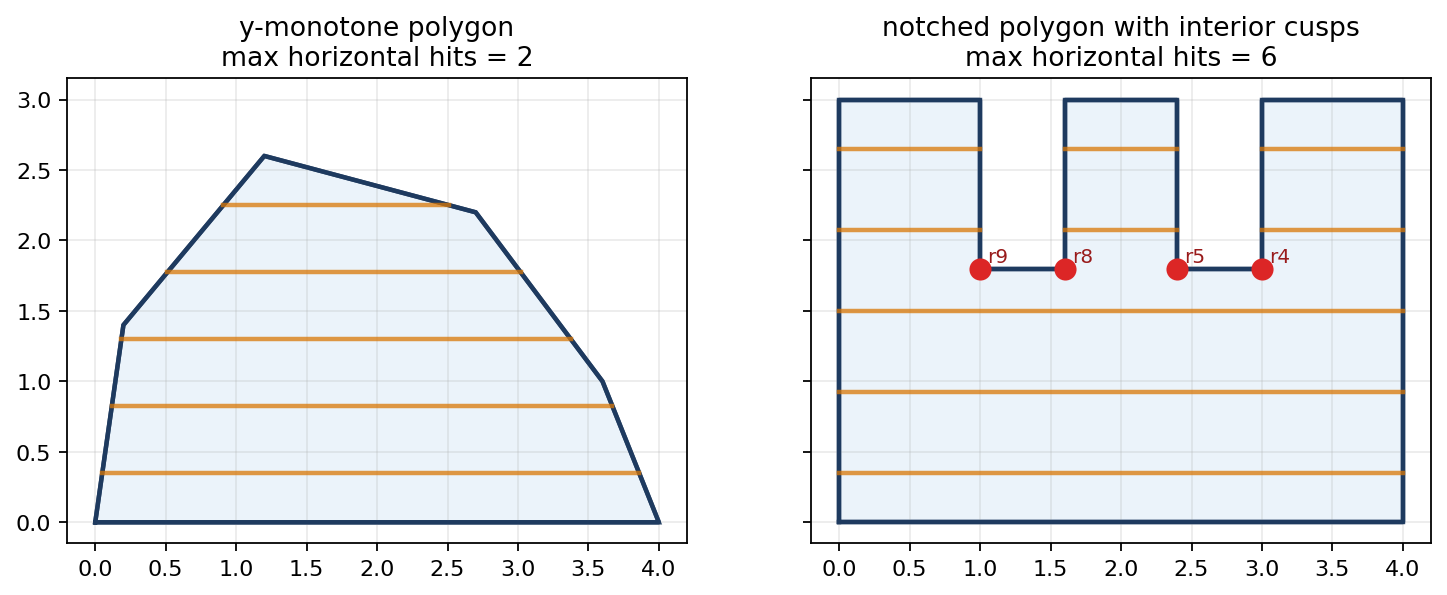

{
  "reflex_vertices": [
    4,
    5,
    8,
    9
  ],
  "notched_max_hits": 6
}


In [2]:
EPS = 1e-9

def signed_area(poly):
    p = np.asarray(poly, float)
    return 0.5 * float(np.sum(p[:, 0] * np.roll(p[:, 1], -1) - np.roll(p[:, 0], -1) * p[:, 1]))

def ensure_ccw(poly):
    p = np.asarray(poly, float)
    return p if signed_area(p) > 0 else p[::-1].copy()

def cross(a, b, c):
    return float(np.cross(np.asarray(b) - np.asarray(a), np.asarray(c) - np.asarray(a)))

def horizontal_intersections(poly, y):
    xs = []
    p = np.asarray(poly, float)
    for a, b in zip(p, np.roll(p, -1, axis=0)):
        if abs(a[1] - b[1]) < EPS:
            continue
        if (a[1] <= y < b[1]) or (b[1] <= y < a[1]):
            x = a[0] + (y - a[1]) * (b[0] - a[0]) / (b[1] - a[1])
            xs.append(float(x))
    return sorted(xs)

def monotone_sample_report(poly, samples=80):
    p = np.asarray(poly, float)
    ys = np.linspace(p[:, 1].min() + 1e-4, p[:, 1].max() - 1e-4, samples)
    counts = [len(horizontal_intersections(p, y)) for y in ys]
    return {"max_intersections": max(counts), "is_y_monotone_by_samples": max(counts) <= 2, "sample_counts": counts}

def reflex_vertices(poly):
    p = ensure_ccw(poly)
    result = []
    for i in range(len(p)):
        prev_i, next_i = (i - 1) % len(p), (i + 1) % len(p)
        if cross(p[prev_i], p[i], p[next_i]) < -EPS:
            result.append(i)
    return result

mono_poly = ensure_ccw(np.array([[0, 0], [4, 0], [3.6, 1.0], [2.7, 2.2], [1.2, 2.6], [0.2, 1.4]], float))
notched_poly = ensure_ccw(np.array([
    [0, 0], [4, 0], [4, 3], [3, 3], [3, 1.8], [2.4, 1.8],
    [2.4, 3], [1.6, 3], [1.6, 1.8], [1, 1.8], [1, 3], [0, 3]
], float))
mono_report = monotone_sample_report(mono_poly)
notched_report = monotone_sample_report(notched_poly)
notch_reflex = reflex_vertices(notched_poly)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, p, title, report in [
    (axes[0], mono_poly, "y-monotone polygon", mono_report),
    (axes[1], notched_poly, "notched polygon with interior cusps", notched_report),
]:
    ax.fill(p[:, 0], p[:, 1], color="#e8f1fa", edgecolor="#1e3a5f", linewidth=2, alpha=0.85)
    ax.plot(np.r_[p[:, 0], p[0, 0]], np.r_[p[:, 1], p[0, 1]], color="#1e3a5f", linewidth=2)
    for y in np.linspace(p[:, 1].min() + 0.35, p[:, 1].max() - 0.35, 5):
        xs = horizontal_intersections(p, y)
        for left, right in zip(xs[::2], xs[1::2]):
            ax.plot([left, right], [y, y], color="#d97706", linewidth=2, alpha=0.75)
    ax.set_title(f"{title}\nmax horizontal hits = {report['max_intersections']}")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.25)
for i in notch_reflex:
    axes[1].scatter(*notched_poly[i], color="#dc2626", s=80, zorder=4)
    axes[1].text(notched_poly[i, 0] + 0.05, notched_poly[i, 1] + 0.05, f"r{i}", color="#991b1b", fontsize=9)
monotone_fig_path = save_matplotlib(fig, FIGURES / "monotone-vs-cusps.png")
plt.close(fig)

monotone_report_path = save_json({
    "monotone_example": mono_report,
    "notched_example": {k: v for k, v in notched_report.items() if k != "sample_counts"},
    "reflex_vertices": [int(i) for i in notch_reflex],
    "checks": {
        "monotone_example_passes": mono_report["is_y_monotone_by_samples"],
        "sampler_detects_nonmonotone_notches": not notched_report["is_y_monotone_by_samples"],
        "notched_polygon_has_four_reflex_vertices": len(notch_reflex) == 4,
    },
}, CHECKS / "monotonicity-and-cusps.json")
display_artifact(monotone_fig_path, width=900)
print(json.dumps({"reflex_vertices": notch_reflex, "notched_max_hits": notched_report["max_intersections"]}, indent=2))


## Trapezoidalization and Monotone Partitioning

Trapezoidalization sweeps across the polygon and records which edge is immediately visible from each cusp in the sweep direction. In a horizontal version, supports through special vertices cut the polygon into trapezoid-like pieces. Those pieces can be assembled into monotone polygons, and monotone polygons can be triangulated efficiently. The chapter's sweep-line description uses a balanced tree of active edges, which is where the `O(n log n)` time bound enters.

The notched example is intentionally orthogonal, so the support diagonals are easy to inspect. The two added diagonals connect matching cusp levels and split the polygon into three rectangles. That is far simpler than a general implementation, but it puts the chapter's logic under a bright lamp: identify the events, insert diagonals that remove split/merge behavior, and then solve each easier piece.


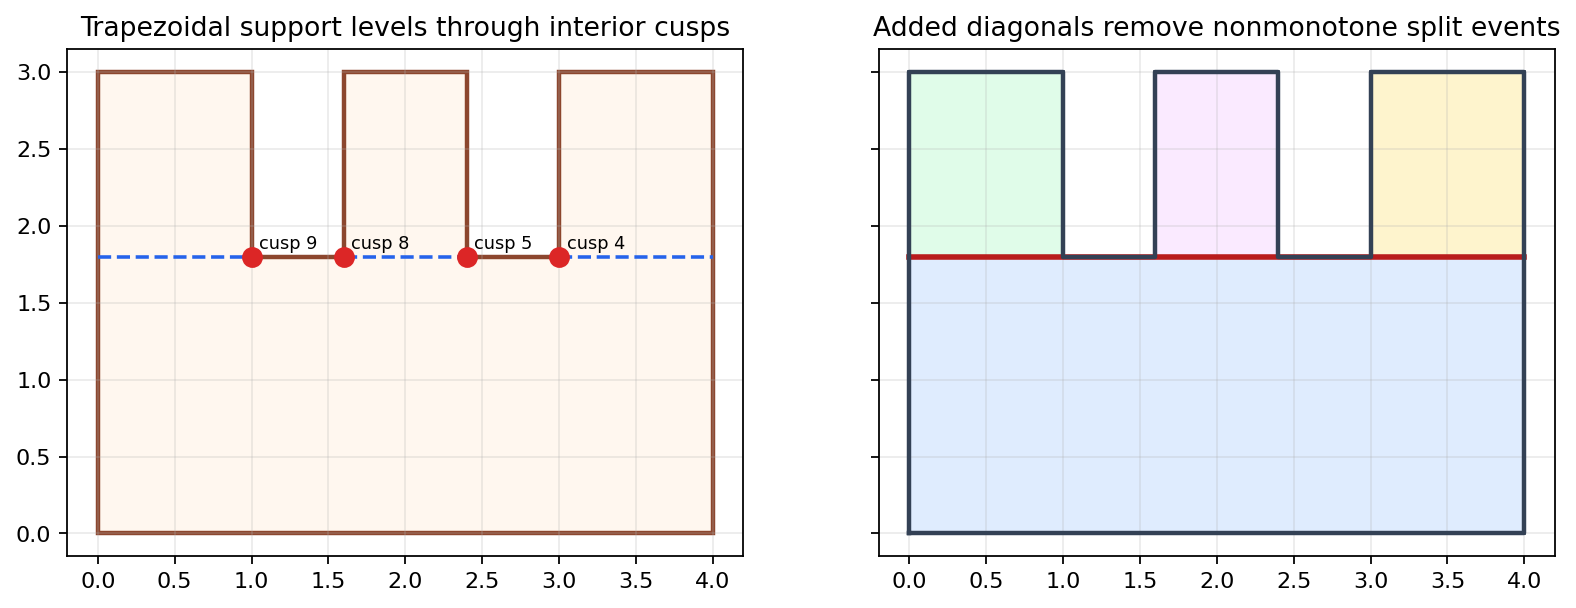

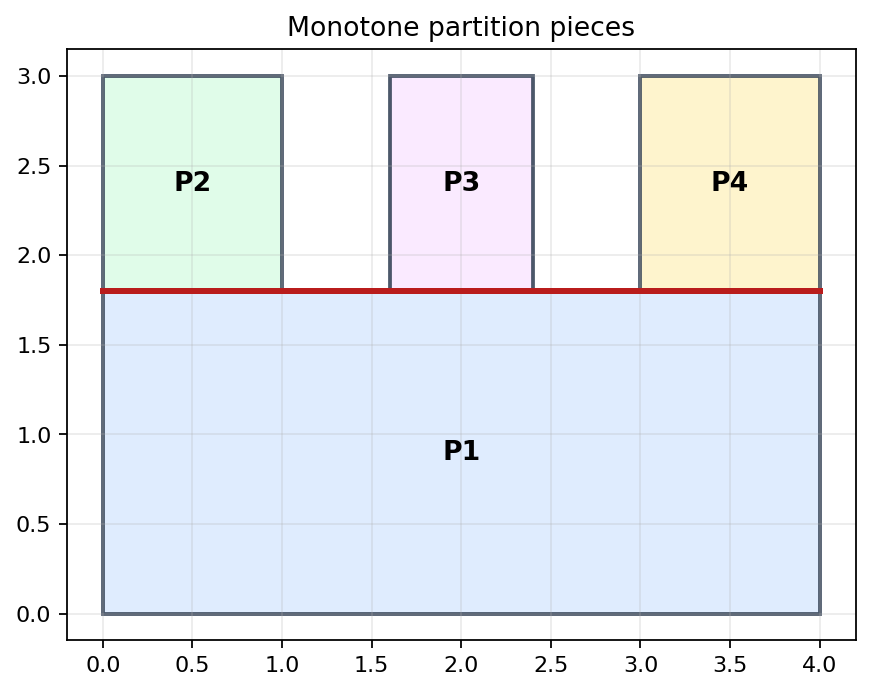

[
  {
    "piece": "P1",
    "vertices": 4,
    "max_horizontal_intersections": 2,
    "y_monotone": true
  },
  {
    "piece": "P2",
    "vertices": 4,
    "max_horizontal_intersections": 2,
    "y_monotone": true
  },
  {
    "piece": "P3",
    "vertices": 4,
    "max_horizontal_intersections": 2,
    "y_monotone": true
  },
  {
    "piece": "P4",
    "vertices": 4,
    "max_horizontal_intersections": 2,
    "y_monotone": true
  }
]


In [3]:
support_levels = sorted(set(float(notched_poly[i, 1]) for i in notch_reflex))
partition_chords = [((0.0, 1.8), (4.0, 1.8))]
partition_pieces = [
    np.array([[0, 0], [4, 0], [4, 1.8], [0, 1.8]], float),
    np.array([[0, 1.8], [1, 1.8], [1, 3], [0, 3]], float),
    np.array([[1.6, 1.8], [2.4, 1.8], [2.4, 3], [1.6, 3]], float),
    np.array([[3, 1.8], [4, 1.8], [4, 3], [3, 3]], float),
]
piece_reports = [monotone_sample_report(piece) for piece in partition_pieces]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
ax = axes[0]
ax.fill(notched_poly[:, 0], notched_poly[:, 1], color="#fff7ed", edgecolor="#7c2d12", linewidth=2, alpha=0.88)
for y in support_levels:
    xs = horizontal_intersections(notched_poly, y + 1e-4)
    for left, right in zip(xs[::2], xs[1::2]):
        ax.plot([left, right], [y, y], color="#2563eb", linestyle="--", linewidth=1.6)
for i in notch_reflex:
    ax.scatter(*notched_poly[i], color="#dc2626", s=70, zorder=4)
    ax.text(notched_poly[i, 0] + 0.05, notched_poly[i, 1] + 0.05, f"cusp {i}", fontsize=8)
ax.set_title("Trapezoidal support levels through interior cusps")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)

ax = axes[1]
colors = ["#dbeafe", "#dcfce7", "#fae8ff", "#fef3c7"]
for piece, color in zip(partition_pieces, colors):
    ax.fill(piece[:, 0], piece[:, 1], color=color, edgecolor="#334155", linewidth=1.7, alpha=0.88)
for a, b in partition_chords:
    ax.plot([a[0], b[0]], [a[1], b[1]], color="#b91c1c", linewidth=2.5)
ax.plot(np.r_[notched_poly[:, 0], notched_poly[0, 0]], np.r_[notched_poly[:, 1], notched_poly[0, 1]], color="#334155", linewidth=2)
ax.set_title("Added diagonals remove nonmonotone split events")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
trapezoid_fig_path = save_matplotlib(fig, FIGURES / "trapezoidal-support-lines.png")
plt.close(fig)

fig, ax = plt.subplots(figsize=(6.8, 4.8))
for k, (piece, color) in enumerate(zip(partition_pieces, colors), 1):
    ax.fill(piece[:, 0], piece[:, 1], color=color, edgecolor="#334155", linewidth=1.7, alpha=0.88)
    c = piece.mean(axis=0)
    ax.text(c[0], c[1], f"P{k}", ha="center", va="center", fontsize=12, weight="bold")
for a, b in partition_chords:
    ax.plot([a[0], b[0]], [a[1], b[1]], color="#b91c1c", linewidth=2.7)
ax.set_title("Monotone partition pieces")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
partition_fig_path = save_matplotlib(fig, FIGURES / "monotone-partition-diagonals.png")
plt.close(fig)

partition_rows = []
for k, (piece, report) in enumerate(zip(partition_pieces, piece_reports), 1):
    partition_rows.append({"piece": f"P{k}", "vertices": len(piece), "max_horizontal_intersections": report["max_intersections"], "y_monotone": report["is_y_monotone_by_samples"]})
partition_table_path = save_csv(partition_rows, TABLES / "monotone-partition-pieces.csv")
partition_report_path = save_json({
    "support_levels": support_levels,
    "partition_chords": [[list(a), list(b)] for a, b in partition_chords],
    "piece_reports": partition_rows,
    "checks": {
        "support_levels_match_cusp_levels": support_levels == [1.8],
        "three_partition_pieces_all_monotone": all(row["y_monotone"] for row in partition_rows),
        "support_chord_present": len(partition_chords) == 1,
    },
}, CHECKS / "trapezoidalization-and-partition.json")
display_artifact(trapezoid_fig_path, width=900)
display_artifact(partition_fig_path, width=650)
print(json.dumps(partition_rows, indent=2))


## Monotone Mountains

A monotone mountain has a base edge and a convex chain above it. The chapter uses mountains because their ear structure is especially clean: convex vertices on the chain can be removed in a controlled way, and this supports linear-time triangulation once the polygon has already been placed in the right structural form. The diagram below uses a fan from one base endpoint to show the same count as ordinary triangulation, while highlighting the chain vertices that act as natural ear tips.


C:\Users\rahul\AppData\Local\Temp\ipykernel_40296\2264665456.py:12: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(np.cross(np.asarray(b) - np.asarray(a), np.asarray(c) - np.asarray(a)))


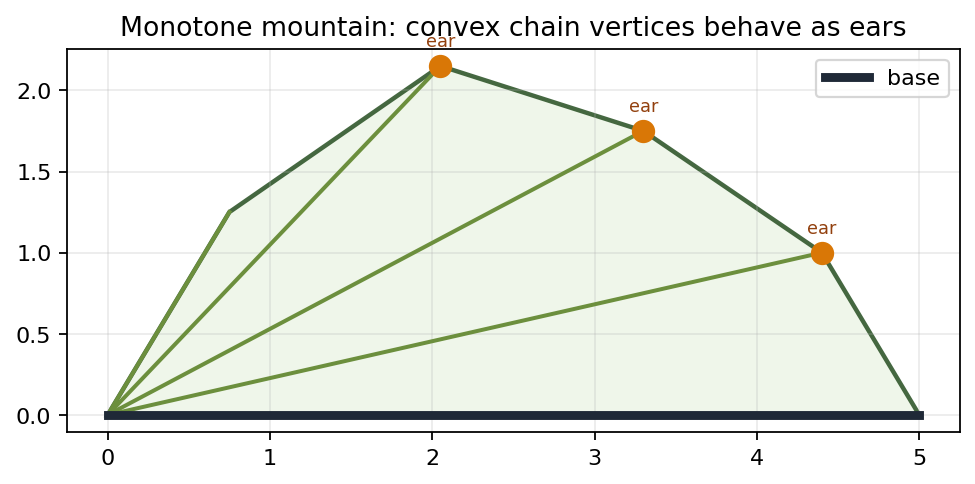

In [4]:
mountain = ensure_ccw(np.array([[0, 0], [5, 0], [4.4, 1.0], [3.3, 1.75], [2.05, 2.15], [0.75, 1.25]], float))
base = (0, 1)
mountain_triangles = [(0, i, i + 1) for i in range(1, len(mountain) - 1)]
chain_ears = list(range(2, len(mountain) - 1))
mountain_area = abs(signed_area(mountain))
mountain_tri_area = sum(abs(cross(mountain[i], mountain[j], mountain[k]) / 2) for i, j, k in mountain_triangles)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.fill(mountain[:, 0], mountain[:, 1], color="#eef6e8", edgecolor="#31572c", linewidth=2, alpha=0.9)
for tri in mountain_triangles:
    i, j, k = tri
    ax.plot([mountain[i, 0], mountain[k, 0]], [mountain[i, 1], mountain[k, 1]], color="#6c8f3d", linewidth=1.8)
for idx in chain_ears:
    ax.scatter(*mountain[idx], color="#d97706", s=90, zorder=4)
    ax.text(mountain[idx, 0], mountain[idx, 1] + 0.12, "ear", ha="center", fontsize=8, color="#92400e")
ax.plot([mountain[0, 0], mountain[1, 0]], [mountain[0, 1], mountain[1, 1]], color="#1f2937", linewidth=4, label="base")
ax.set_title("Monotone mountain: convex chain vertices behave as ears")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")
mountain_fig_path = save_matplotlib(fig, FIGURES / "monotone-mountain-ears.png")
plt.close(fig)

mountain_report_path = save_json({
    "vertices": int(len(mountain)),
    "triangles": [list(map(int, tri)) for tri in mountain_triangles],
    "chain_ear_vertices": chain_ears,
    "area": mountain_area,
    "triangle_area_sum": mountain_tri_area,
    "checks": {
        "mountain_has_n_minus_two_triangles": len(mountain_triangles) == len(mountain) - 2,
        "fan_area_matches_mountain_area": abs(mountain_area - mountain_tri_area) < 1e-9,
        "chain_has_visible_ears": len(chain_ears) >= 2,
    },
}, CHECKS / "monotone-mountain-checks.json")
display_artifact(mountain_fig_path, width=700)


## Convex Partition Bounds and Algorithm Roles

Triangulation always gives convex pieces, but often too many of them. Convex partitioning asks how many larger convex pieces are necessary. Reflex vertices are the main obstruction. A single convex piece has no reflex vertex; each diagonal can remove at most two units of reflex difficulty, so the lower bound `ceil(r/2)+1` appears. A simple constructive upper bound uses at most `r+1` pieces. The Hertel-Mehlhorn idea starts from a triangulation and removes diagonals whose deletion preserves convexity, yielding a fast approximation rather than a guaranteed optimum.

For the notched example, the two diagonals split the polygon into four rectangles. The count is within the source bounds for `r=4`: the lower bound is 3 and the simple upper bound is 5. This particular partition is not claimed to be optimal; it is a visible check of the theorem's scale and a reminder that a partition can be useful even when it is not minimum.


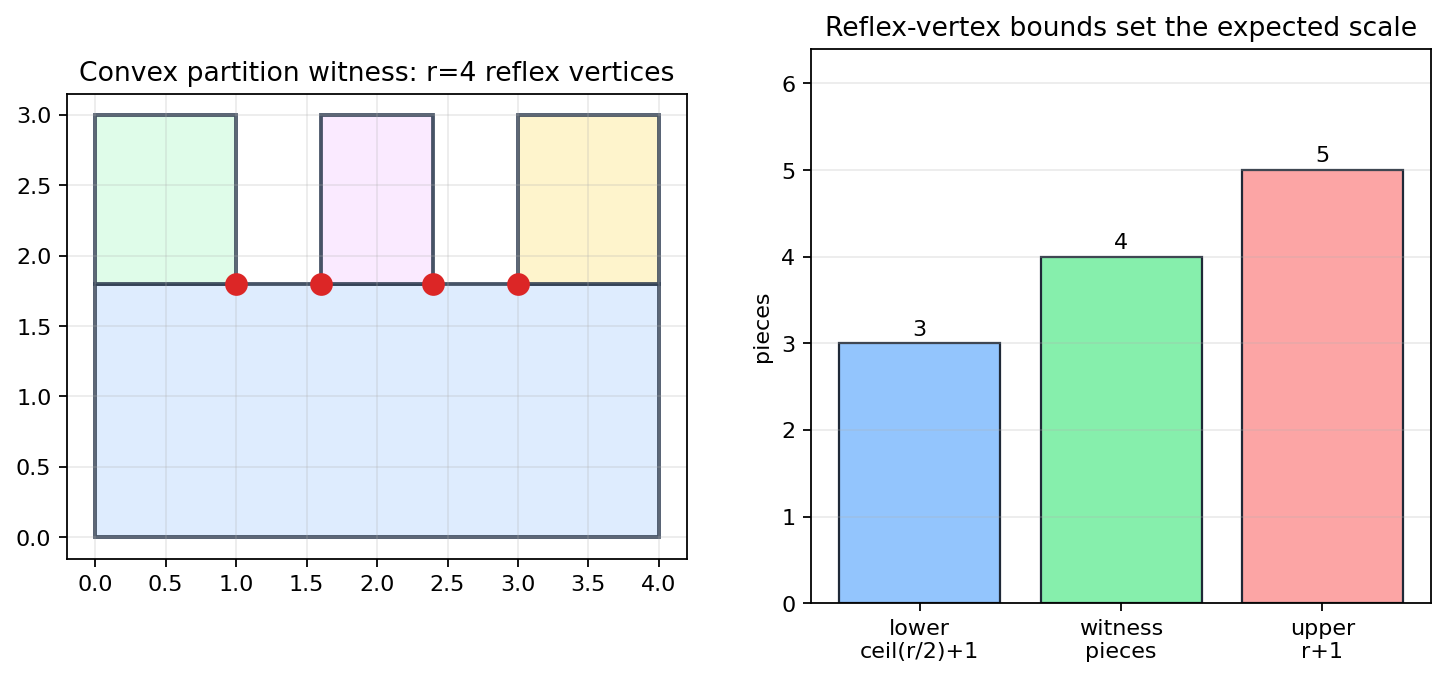

{
  "reflex_count": 4,
  "bounds": [
    3,
    4,
    5
  ]
}


In [5]:
r = len(notch_reflex)
lower_bound = math.ceil(r / 2) + 1
upper_bound = r + 1
piece_count = len(partition_pieces)
algorithm_rows = [
    {"method": "trapezoidalization", "role": "find support diagonals", "typical_bound": "O(n log n)", "chapter_note": "sweep with active-edge structure"},
    {"method": "monotone triangulation", "role": "triangulate each monotone piece", "typical_bound": "linear per piece", "chapter_note": "stack/order logic"},
    {"method": "Chazelle", "role": "optimal triangulation time", "typical_bound": "O(n)", "chapter_note": "deep theoretical result"},
    {"method": "Seidel", "role": "randomized practical triangulation", "typical_bound": "O(n log* n)", "chapter_note": "foreshadows point-location structure"},
    {"method": "Hertel-Mehlhorn", "role": "convex partition approximation", "typical_bound": "within constant factor", "chapter_note": "remove inessential diagonals"},
]
algorithm_table_path = save_csv(algorithm_rows, TABLES / "algorithm-role-map.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ax = axes[0]
for piece, color in zip(partition_pieces, colors):
    ax.fill(piece[:, 0], piece[:, 1], color=color, edgecolor="#334155", linewidth=1.7, alpha=0.9)
for i in notch_reflex:
    ax.scatter(*notched_poly[i], color="#dc2626", s=85, zorder=4)
ax.set_title(f"Convex partition witness: r={r} reflex vertices")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)

ax = axes[1]
labels = ["lower\nceil(r/2)+1", "witness\npieces", "upper\nr+1"]
values = [lower_bound, piece_count, upper_bound]
bars = ax.bar(labels, values, color=["#93c5fd", "#86efac", "#fca5a5"], edgecolor="#1f2937")
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.05, str(value), ha="center", va="bottom")
ax.set_ylim(0, max(values) + 1.4)
ax.set_ylabel("pieces")
ax.set_title("Reflex-vertex bounds set the expected scale")
ax.grid(True, axis="y", alpha=0.25)
convex_fig_path = save_matplotlib(fig, FIGURES / "convex-partition-bounds.png")
plt.close(fig)

convex_report_path = save_json({
    "reflex_vertices": [int(i) for i in notch_reflex],
    "reflex_count": r,
    "lower_bound": lower_bound,
    "partition_piece_count": piece_count,
    "upper_bound": upper_bound,
    "checks": {
        "piece_count_respects_reflex_bounds": lower_bound <= piece_count <= upper_bound,
        "upper_bound_is_r_plus_one": upper_bound == r + 1,
        "lower_bound_is_ceil_r_over_two_plus_one": lower_bound == math.ceil(r / 2) + 1,
    },
}, CHECKS / "convex-partition-bounds.json")
display_artifact(convex_fig_path, width=900)
print(json.dumps({"reflex_count": r, "bounds": [lower_bound, piece_count, upper_bound]}, indent=2))


## Applied Lab

Move one notch of the notched polygon inward or outward and rerun the notebook. If the horizontal sampler begins to report only two intersections at every sampled level, the monotone partition no longer needs both diagonals. If a notch introduces another reflex pair, the lower and upper bounds change immediately. This is exactly the chapter's message: the right preprocessing step depends on the local events that make the polygon hard.

A second experiment is to replace the rectangle partition with a triangulation and then remove diagonals whose removal leaves a convex quadrilateral. The piece count should drop, but it should remain constrained by the reflex ledger. That is the computational feel of Hertel-Mehlhorn: begin with a triangulation because it is easy to trust, then delete only those diagonals whose absence is certified by convexity.


## Takeaways

Polygon partitioning is the chapter where triangulation becomes a strategy rather than a single algorithm. Monotone polygons are easier than arbitrary polygons, mountains are easier still, and convex pieces are often more useful than many tiny triangles. Trapezoidalization supplies a systematic way to find useful cuts, while reflex vertices explain why some cuts are unavoidable. The asymptotic story is also important: sweep methods give accessible `O(n log n)` algorithms, Chazelle proves linear time is possible, Seidel provides a randomized route, and Hertel-Mehlhorn shows how a triangulation can be simplified for convex partitioning.

The notebook's checks are intentionally structural: a sampler detects nonmonotonicity, support levels match cusp levels, partition pieces pass the monotonicity test, the mountain triangulation has `n-2` triangles, and the convex partition count lies between the reflex-vertex bounds. These checks do not replace a robust production implementation, but they make the chapter standalone by tying every visual cut to a formal reason for making it.


In [6]:
# final_sanity
final_sanity = {
    "unit": UNIT_TITLE,
    "artifact_count": 13,
    "checks": {
        "monotone_example_passes": mono_report["is_y_monotone_by_samples"],
        "sampler_detects_nonmonotone_notches": not notched_report["is_y_monotone_by_samples"],
        "notched_polygon_has_four_reflex_vertices": len(notch_reflex) == 4,
        "support_levels_match_cusp_levels": support_levels == [1.8],
        "three_partition_pieces_all_monotone": all(row["y_monotone"] for row in partition_rows),
        "mountain_has_n_minus_two_triangles": len(mountain_triangles) == len(mountain) - 2,
        "piece_count_respects_reflex_bounds": lower_bound <= piece_count <= upper_bound,
    },
    "artifacts": [
        str(storyboard_path), str(routing_path), str(coverage_path),
        str(monotone_fig_path), str(monotone_report_path), str(trapezoid_fig_path), str(partition_fig_path),
        str(partition_table_path), str(partition_report_path), str(mountain_fig_path), str(mountain_report_path),
        str(algorithm_table_path), str(convex_fig_path), str(convex_report_path),
    ],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final-sanity.json")
assert all(final_sanity["checks"].values()), json.dumps(final_sanity["checks"], indent=2)
assert_artifacts([Path(p) for p in final_sanity["artifacts"]] + [final_sanity_path], min_bytes=40)
print(json.dumps({"final_sanity": "passed", "checks": final_sanity["checks"]}, indent=2))


{
  "final_sanity": "passed",
  "checks": {
    "monotone_example_passes": true,
    "sampler_detects_nonmonotone_notches": true,
    "notched_polygon_has_four_reflex_vertices": true,
    "support_levels_match_cusp_levels": true,
    "three_partition_pieces_all_monotone": true,
    "mountain_has_n_minus_two_triangles": true,
    "piece_count_respects_reflex_bounds": true
  }
}
